In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

In [ ]:
ipl = pd.read_csv('ipl.csv')

In [ ]:
ipl.shape

(76014, 15)

In [ ]:
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [ ]:
ipl.isnull().sum()

,0
mid,0
date,0
venue,0
bat_team,0
bowl_team,0
batsman,0
bowler,0
runs,0
wickets,0
overs,0


In [ ]:
ipl.duplicated().sum()

np.int64(0)

In [ ]:
ipl = ipl.drop(columns=['mid','venue','batsman','bowler','striker','non-striker'])

In [ ]:
ipl.shape

(76014, 9)

In [ ]:
ipl['bat_team'].unique()

array(['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
       'Mumbai Indians', 'Deccan Chargers', 'Kings XI Punjab',
       'Royal Challengers Bangalore', 'Delhi Daredevils',
       'Kochi Tuskers Kerala', 'Pune Warriors', 'Sunrisers Hyderabad',
       'Rising Pune Supergiants', 'Gujarat Lions',
       'Rising Pune Supergiant'], dtype=object)

In [ ]:
consistent_teams = ['Kolkata Knight Riders', 'Chennai Super Kings', 'Rajasthan Royals',
                    'Mumbai Indians', 'Kings XI Punjab', 'Royal Challengers Bangalore',
                    'Delhi Daredevils', 'Sunrisers Hyderabad']

In [ ]:
print('Before removing inconsistent teams: {}'.format(ipl.shape))
ipl = ipl[(ipl['bat_team'].isin(consistent_teams)) & (ipl['bowl_team'].isin(consistent_teams))]
print('After removing inconsistent teams: {}'.format(ipl.shape))

Before removing inconsistent teams: (76014, 9)
After removing inconsistent teams: (53811, 9)


In [ ]:
ipl = ipl[ipl["overs"] >= 5]
print(ipl["overs"].min())  # should now be 5.0


5.0


In [ ]:
ipl.shape

(40108, 9)

In [ ]:
ipl["date"] = pd.to_datetime(ipl["date"], errors="coerce")

ipl["year"] = ipl["date"].dt.year
ipl["month"] = ipl["date"].dt.month
ipl["day"] = ipl["date"].dt.day
ipl["day_name"] = ipl["date"].dt.day_name()

print(ipl[["date", "year", "month", "day", "day_name"]].head())


         date  year  month  day day_name
32 2008-04-18  2008      4   18   Friday
33 2008-04-18  2008      4   18   Friday
34 2008-04-18  2008      4   18   Friday
35 2008-04-18  2008      4   18   Friday
36 2008-04-18  2008      4   18   Friday


In [ ]:
numeric_cols=["runs","wickets","overs","runs_last_5","wickets_last_5","total"]
corr_matrix=ipl[numeric_cols].corr()

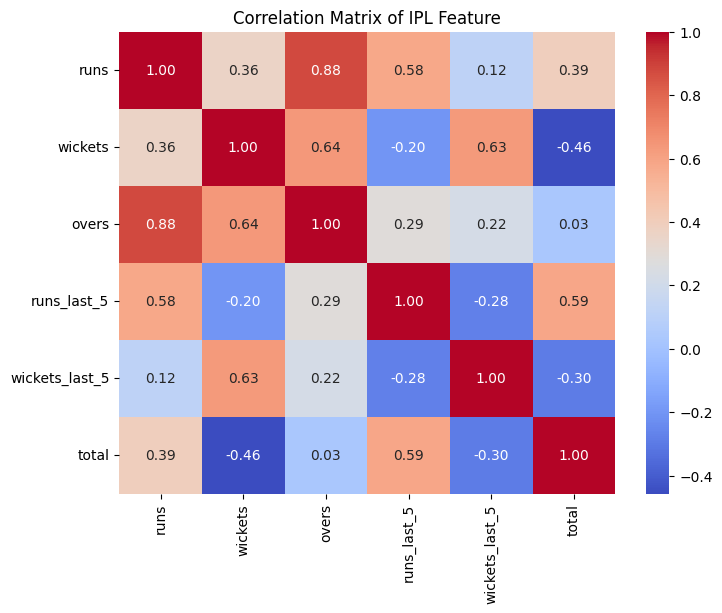

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt=".2f")
plt.title('Correlation Matrix of IPL Feature')
plt.show()

In [ ]:
# le = LabelEncoder()
# for col in ipl.select_dtypes(include='object').columns:
#   ipl[col] = le.fit_transform(ipl[col])

In [ ]:
# X = ipl.drop(columns=["total","date"],axis=1)
# y = ipl['total']
# X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=1)
# model = LinearRegression()
# model.fit(X_train,y_train)

In [ ]:
# print("Intercept:", model.intercept_)
# print("Coefficients:", model.coef_)

In [ ]:
# y_pred = model.predict(X_test)
# print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
# print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
# print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
# print('R2 Score:', r2_score(y_test, y_pred))

In [ ]:
encoded_ipl = pd.get_dummies(data=ipl, columns=['bat_team', 'bowl_team'])
encoded_ipl.columns

Index(['date', 'runs', 'wickets', 'overs', 'runs_last_5', 'wickets_last_5',
       'total', 'year', 'month', 'day', 'day_name',
       'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils',
       'bat_team_Kings XI Punjab', 'bat_team_Kolkata Knight Riders',
       'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
       'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
       'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils',
       'bowl_team_Kings XI Punjab', 'bowl_team_Kolkata Knight Riders',
       'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
       'bowl_team_Royal Challengers Bangalore',
       'bowl_team_Sunrisers Hyderabad'],
      dtype='object')

In [ ]:
encoded_ipl = encoded_ipl[['date', 'bat_team_Chennai Super Kings', 'bat_team_Delhi Daredevils', 'bat_team_Kings XI Punjab',
              'bat_team_Kolkata Knight Riders', 'bat_team_Mumbai Indians', 'bat_team_Rajasthan Royals',
              'bat_team_Royal Challengers Bangalore', 'bat_team_Sunrisers Hyderabad',
              'bowl_team_Chennai Super Kings', 'bowl_team_Delhi Daredevils', 'bowl_team_Kings XI Punjab',
              'bowl_team_Kolkata Knight Riders', 'bowl_team_Mumbai Indians', 'bowl_team_Rajasthan Royals',
              'bowl_team_Royal Challengers Bangalore', 'bowl_team_Sunrisers Hyderabad',
              'overs', 'runs', 'wickets', 'runs_last_5', 'wickets_last_5', 'total']]

In [ ]:
# Splitting the data into train and test set
X_train = encoded_ipl.drop(labels='total', axis=1)[encoded_ipl['date'].dt.year <= 2016]
X_test = encoded_ipl.drop(labels='total', axis=1)[encoded_ipl['date'].dt.year >= 2017]

y_train = encoded_ipl[encoded_ipl['date'].dt.year <= 2016]['total'].values
y_test = encoded_ipl[encoded_ipl['date'].dt.year >= 2017]['total'].values

# Removing the 'date' column
X_train.drop(labels='date', axis=True, inplace=True)
X_test.drop(labels='date', axis=True, inplace=True)

print("Training set: {} and Test set: {}".format(X_train.shape, X_test.shape))

Training set: (37330, 21) and Test set: (2778, 21)


In [ ]:
model = LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
print('Mean Absolute Error:', mean_absolute_error(y_test, y_pred))
print('Mean Squared Error:', mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 Score:', r2_score(y_test, y_pred))

Mean Absolute Error: 12.118617546193299
Mean Squared Error: 251.00792310417438
RMSE: 15.843229566732106
R2 Score: 0.7522633566350527


In [ ]:
dc = DecisionTreeRegressor()
dc.fit(X_train,y_train)

DecisionTreeRegressor()

In [ ]:
print('MSE', mean_squared_error(y_test,dc.predict(X_test)))
print('MAE', mean_absolute_error(y_test,dc.predict(X_test)))
print('RMSE', np.sqrt(mean_squared_error(y_test,dc.predict(X_test))))
print('R2 Score', r2_score(y_test,dc.predict(X_test)))

MSE 520.8887688984881
MAE 16.945644348452124
RMSE 22.822987729446996
R2 Score 0.4858997533721072


In [ ]:
rf = RandomForestRegressor()
rf.fit(X_train,y_train)

RandomForestRegressor()

In [ ]:
print('MSE', mean_squared_error(y_test,rf.predict(X_test)))
print('MAE', mean_absolute_error(y_test,rf.predict(X_test)))
print('RMSE', np.sqrt(mean_squared_error(y_test,rf.predict(X_test))))
print('R2 Score', r2_score(y_test,rf.predict(X_test)))

MSE 328.5515230451764
MAE 13.666240220782337
RMSE 18.12599026384976
R2 Score 0.675730349524176


In [ ]:
match_data = ipl[(ipl['bat_team'] == 'Kolkata Knight Riders') & (ipl['bowl_team'] == 'Delhi Daredevils')]
match_data.head()

,date,bat_team,bowl_team,runs,wickets,overs,runs_last_5,wickets_last_5,total,year,month,day,day_name
4310,2008-05-13,Kolkata Knight Riders,Delhi Daredevils,29,0,5.0,28,0,133,2008,5,13,Tuesday
4311,2008-05-13,Kolkata Knight Riders,Delhi Daredevils,29,0,5.1,28,0,133,2008,5,13,Tuesday
4312,2008-05-13,Kolkata Knight Riders,Delhi Daredevils,33,0,5.2,31,0,133,2008,5,13,Tuesday
4313,2008-05-13,Kolkata Knight Riders,Delhi Daredevils,34,0,5.2,32,0,133,2008,5,13,Tuesday
4314,2008-05-13,Kolkata Knight Riders,Delhi Daredevils,34,0,5.3,31,0,133,2008,5,13,Tuesday


In [ ]:
sample_input = {
    "bat_team": "Kolkata Knight Riders",
    "bowl_team": "Delhi Daredevils",
    "runs": 120,
    "wickets": 3,
    "overs": 15.0,
    "runs_last_5": 45,
    "wickets_last_5": 1,
    "toss_decision": 1,
    "year": 2018
}

In [ ]:
sample_ipl = pd.DataFrame(sample_input, index=[0])
sample_ipl = pd.get_dummies(sample_ipl)
sample_ipl = sample_ipl.reindex(columns=X_train.columns, fill_value=0)

predicted_score = model.predict(sample_ipl)
print("Predicted Score:", predicted_score)
print("Score Range:",int(predicted_score-(predicted_score*0.1)),
      int(predicted_score+(predicted_score*0.1)))

Predicted Score: [167.07580595]
Score Range: 150 183


/tmp/ipykernel_4362/2029728201.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Score Range:",int(predicted_score-(predicted_score*0.1)),
/tmp/ipykernel_4362/2029728201.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(predicted_score+(predicted_score*0.1)))


In [ ]:
bat_team = "Kolkata Knight Riders"
bowl_team = "Delhi Daredevils"

matches = [
    ("Kolkata Knight Riders", "Delhi Daredevils"),
    ("Sunrisers Hyderabad", "Royal Challengers Bangalore"),
    ("Mumbai Indians", "Chennai Super Kings"),
    ("Rajasthan Royals", "Kings XI Punjab"),
    ("Delhi Daredevils", "Mumbai Indians"),
    ("Chennai Super Kings", "Kolkata Knight Riders"),
    ("Royal Challengers Bangalore", "Sunrisers Hyderabad")
]
pred_input = pd.DataFrame(
    0,
    index=[0],
    columns=X_train.columns
)

pred_input[f"bat_team_{team_map[bat_team]}"] = 1
pred_input[f"bowl_team_{team_map[bowl_team]}"] = 1

In [ ]:
pred_input['bat_team_Kolkata Knight Riders'] = 1
pred_input['bowl_team_Delhi Daredevils'] = 1
pred_input['overs'] = 10.5
pred_input['runs'] = 85
pred_input['wickets'] = 3
pred_input['runs_last_5'] = 10
pred_input['wickets_last_5'] = 2

In [ ]:
prediction1 = model.predict(pred_input)[0]

print("Predicted Score: ", prediction1)

print("Score Range:",
      int(prediction1 - (prediction1 * 0.1)),
      int(prediction1 + (prediction1 * 0.1)))

Predicted Score:  161.46403694080232
Score Range: 145 177


In [ ]:
sample_input = {
    "bat_team": "Sunrisers Hyderabad",
    "bowl_team": "Royal Challengers Bangalore",
    "runs": 130,
    "wickets": 4,
    "overs": 16.0,
    "runs_last_5": 50,
    "wickets_last_5": 1,
    "toss_decision": 1,
    "year": 2018
}

In [ ]:
prediction1 = model.predict(pred_input)[0]

print("Predicted Score: ", prediction1)

print("Score Range:",
      int(prediction1 - (prediction1 * 0.1)),
      int(prediction1 + (prediction1 * 0.1)))

Predicted Score:  161.46403694080232
Score Range: 145 177
